# 3D Deformation Field Correction — Test Cases

This notebook tests the 3D extension of the iterative SLSQP algorithm for
correcting negative Jacobian determinants in volumetric deformation fields.

Deformation fields have shape `(3, D, H, W)` with channels `[dz, dy, dx]`.
The 3D Jacobian determinant is the determinant of the 3×3 deformation
gradient tensor `det(I + ∇u)`, computed via `np.gradient` central differences.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from dvfopt import (
    generate_random_dvf_3d,
    scale_dvf_3d,
    jacobian_det3D,
    iterative_3d,
)

## Sanity Check — Identity Deformation

A zero displacement field should have Jacobian determinant = 1.0 everywhere.

In [2]:
zero_dvf = np.zeros((3, 5, 5, 5))
jdet_zero = jacobian_det3D(zero_dvf)
print(f"Shape: {jdet_zero.shape}")
print(f"Min: {jdet_zero.min():.6f}  Max: {jdet_zero.max():.6f}")
assert np.allclose(jdet_zero, 1.0), "Identity Jdet should be 1.0 everywhere"
print("PASS: Identity deformation has Jdet = 1.0 everywhere")

Shape: (5, 5, 5)
Min: 1.000000  Max: 1.000000
PASS: Identity deformation has Jdet = 1.0 everywhere


## Helper — Summarise Jacobian Stats

In [3]:
def jdet_summary(dvf, label="DVF"):
    """Print Jacobian determinant summary for a (3, D, H, W) field."""
    jdet = jacobian_det3D(dvf)
    neg = int((jdet <= 0).sum())
    total = jdet.size
    print(f"{label}:  shape={dvf.shape[1:]}  "
          f"neg={neg}/{total}  min={jdet.min():.6f}  max={jdet.max():.6f}")
    return jdet

---
## Test Case 1 — Small Cubic Grid (5×5×5)

Random DVF with moderate magnitude. Small enough for fast SLSQP convergence.

In [4]:
dvf_1 = generate_random_dvf_3d((3, 5, 5, 5), max_magnitude=2.0, seed=42)
jdet_before_1 = jdet_summary(dvf_1, "Case 1 — before")

phi_1 = iterative_3d(dvf_1, verbose=1)

jdet_after_1 = jdet_summary(phi_1, "Case 1 — after")
assert (jdet_after_1 > 0).all(), "All Jdet must be positive after correction"

Case 1 — before:  shape=(5, 5, 5)  neg=58/125  min=-17.098767  max=15.962321
[init] Grid 5x5x5  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet voxels: 58  |  min Jdet: -17.098767
[iter    1]  fix (  3,  1,  4)  win 5x5x5  neg_jdet     0  min_jdet +0.010000  L2 5.4166  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — 3D)
------------------------------------------------------------
  Grid size        : 5 x 5 x 5
  Iterations       : 1
  Neg-Jdet     58 ->     0
  Min Jdet  -17.098767 -> +0.010000
  L2 error         : 5.416597
  Time             : 1.84s
Case 1 — after:  shape=(5, 5, 5)  neg=0/125  min=0.010000  max=14.280134


---
## Test Case 2 — Non-Cubic Grid (4×6×5)

Tests rectangular sub-volume handling and full-grid fallback.

In [5]:
dvf_2 = generate_random_dvf_3d((3, 4, 6, 5), max_magnitude=1.5, seed=123)
jdet_before_2 = jdet_summary(dvf_2, "Case 2 — before")

phi_2 = iterative_3d(dvf_2, verbose=1)

jdet_after_2 = jdet_summary(phi_2, "Case 2 — after")
assert (jdet_after_2 > 0).all(), "All Jdet must be positive after correction"

Case 2 — before:  shape=(4, 6, 5)  neg=39/120  min=-8.126892  max=16.936625
[init] Grid 4x6x5  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet voxels: 39  |  min Jdet: -8.126892
[iter    1]  fix (  0,  0,  0)  win 4x6x5  neg_jdet     0  min_jdet +0.010000  L2 2.3854  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — 3D)
------------------------------------------------------------
  Grid size        : 4 x 6 x 5
  Iterations       : 1
  Neg-Jdet     39 ->     0
  Min Jdet  -8.126892 -> +0.010000
  L2 error         : 2.385355
  Time             : 1.18s
Case 2 — after:  shape=(4, 6, 5)  neg=0/120  min=0.010000  max=17.450159


---
## Test Case 3 — Upscaled Smooth DVF (3×3×3 → 8×8×8)

Generate a coarse random field and upscale with trilinear interpolation.
This produces a smoother field with fewer but larger negative-Jdet regions.

In [6]:
dvf_coarse = generate_random_dvf_3d((3, 3, 3, 3), max_magnitude=4.0, seed=7)
dvf_3 = scale_dvf_3d(dvf_coarse, (8, 8, 8))
jdet_before_3 = jdet_summary(dvf_3, "Case 3 — before")

phi_3 = iterative_3d(dvf_3, verbose=1)

jdet_after_3 = jdet_summary(phi_3, "Case 3 — after")
assert (jdet_after_3 > 0).all(), "All Jdet must be positive after correction"

Case 3 — before:  shape=(8, 8, 8)  neg=233/512  min=-38.192108  max=49.527997
[init] Grid 8x8x8  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet voxels: 233  |  min Jdet: -38.192108
[iter    1]  fix (  7,  0,  4)  win 8x8x8  neg_jdet     0  min_jdet +0.010000  L2 17.2245  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — 3D)
------------------------------------------------------------
  Grid size        : 8 x 8 x 8
  Iterations       : 1
  Neg-Jdet    233 ->     0
  Min Jdet  -38.192108 -> +0.010000
  L2 error         : 17.224527
  Time             : 41.66s
Case 3 — after:  shape=(8, 8, 8)  neg=0/512  min=0.010000  max=48.004571


---
## Test Case 4 — Real Data: Slice 350 Crop (5×10×10)

Cropped from the full 3D Elastix registration deformation field
(`deformation3d.npy`), centred on the worst negative-Jdet cluster
around axial slice 350.

In [7]:
dvf_4 = np.load("data/test_cases_3d/slice350_5x10x10.npy")
jdet_before_4 = jdet_summary(dvf_4, "Case 4 — before")

phi_4 = iterative_3d(dvf_4, verbose=1)

jdet_after_4 = jdet_summary(phi_4, "Case 4 — after")
assert (jdet_after_4 > 0).all(), "All Jdet must be positive after correction"

Case 4 — before:  shape=(5, 10, 10)  neg=22/500  min=-9.703427  max=23.525388
[init] Grid 5x10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet voxels: 22  |  min Jdet: -9.703427
[iter    1]  fix (  1,  5,  5)  win 3x7x5  neg_jdet    15  min_jdet -6.936654  L2 2.8691  sub-iters 1
[iter    2]  fix (  3,  8,  5)  win 3x4x6  neg_jdet    10  min_jdet -2.535579  L2 3.8120  sub-iters 1
[iter    3]  fix (  2,  5,  2)  win 5x10x9  neg_jdet     1  min_jdet -0.297288  L2 3.6375  sub-iters 4
[iter    4]  fix (  3,  5,  9)  win 3x3x3  neg_jdet     0  min_jdet +0.006457  L2 3.6545  sub-iters 1
[iter    5]  fix (  0,  2,  9)  win 3x3x3  neg_jdet     0  min_jdet +0.010000  L2 3.6546  sub-iters 1
[done] All Jdet > threshold after iter 5

  SUMMARY  (SLSQP — 3D)
------------------------------------------------------------
  Grid size        : 5 x 10 x 10
  Iterations       : 5
  Neg-Jdet     22 ->     0
  Min Jdet  -9.703427 -> +0.010000
  L2 error         : 3.654587
  Time             : 25.22s
C

---
## Test Case 5 — Real Data: Slice 200 Crop (5×10×10)

Same extraction around axial slice 200.

In [8]:
dvf_5 = np.load("data/test_cases_3d/slice200_5x10x10.npy")
jdet_before_5 = jdet_summary(dvf_5, "Case 5 — before")

phi_5 = iterative_3d(dvf_5, verbose=1)

jdet_after_5 = jdet_summary(phi_5, "Case 5 — after")
assert (jdet_after_5 > 0).all(), "All Jdet must be positive after correction"

Case 5 — before:  shape=(5, 10, 10)  neg=12/500  min=-5.970835  max=6.529563
[init] Grid 5x10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet voxels: 12  |  min Jdet: -5.970835
[iter    1]  fix (  4,  5,  5)  win 4x6x5  neg_jdet     5  min_jdet -2.380132  L2 0.9772  sub-iters 1
[iter    2]  fix (  3,  9,  7)  win 5x5x5  neg_jdet     0  min_jdet +0.010000  L2 1.6459  sub-iters 2
[done] All Jdet > threshold after iter 2

  SUMMARY  (SLSQP — 3D)
------------------------------------------------------------
  Grid size        : 5 x 10 x 10
  Iterations       : 2
  Neg-Jdet     12 ->     0
  Min Jdet  -5.970835 -> +0.010000
  L2 error         : 1.645906
  Time             : 5.00s
Case 5 — after:  shape=(5, 10, 10)  neg=0/500  min=0.010000  max=6.509260


---
## Test Case 6 — Real Data: Slice 90 Crop (5×10×10)

Same extraction around axial slice 90.

In [9]:
dvf_6 = np.load("data/test_cases_3d/slice090_5x10x10.npy")
jdet_before_6 = jdet_summary(dvf_6, "Case 6 — before")

phi_6 = iterative_3d(dvf_6, verbose=1)

jdet_after_6 = jdet_summary(phi_6, "Case 6 — after")
assert (jdet_after_6 > 0).all(), "All Jdet must be positive after correction"

Case 6 — before:  shape=(5, 10, 10)  neg=20/500  min=-6.509779  max=10.070270
[init] Grid 5x10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet voxels: 20  |  min Jdet: -6.509779
[iter    1]  fix (  2,  5,  5)  win 4x6x4  neg_jdet    14  min_jdet -2.491765  L2 2.4553  sub-iters 1
[iter    2]  fix (  2,  5,  3)  win 5x7x6  neg_jdet     4  min_jdet -0.531542  L2 2.6416  sub-iters 1
[iter    3]  fix (  4,  9,  6)  win 3x3x3  neg_jdet     2  min_jdet -0.431098  L2 2.6481  sub-iters 1
[iter    4]  fix (  3,  5,  0)  win 3x3x3  neg_jdet     0  min_jdet +0.010000  L2 2.6724  sub-iters 1
[done] All Jdet > threshold after iter 4

  SUMMARY  (SLSQP — 3D)
------------------------------------------------------------
  Grid size        : 5 x 10 x 10
  Iterations       : 4
  Neg-Jdet     20 ->     0
  Min Jdet  -6.509779 -> +0.010000
  L2 error         : 2.672445
  Time             : 9.99s
Case 6 — after:  shape=(5, 10, 10)  neg=0/500  min=0.010000  max=9.164031


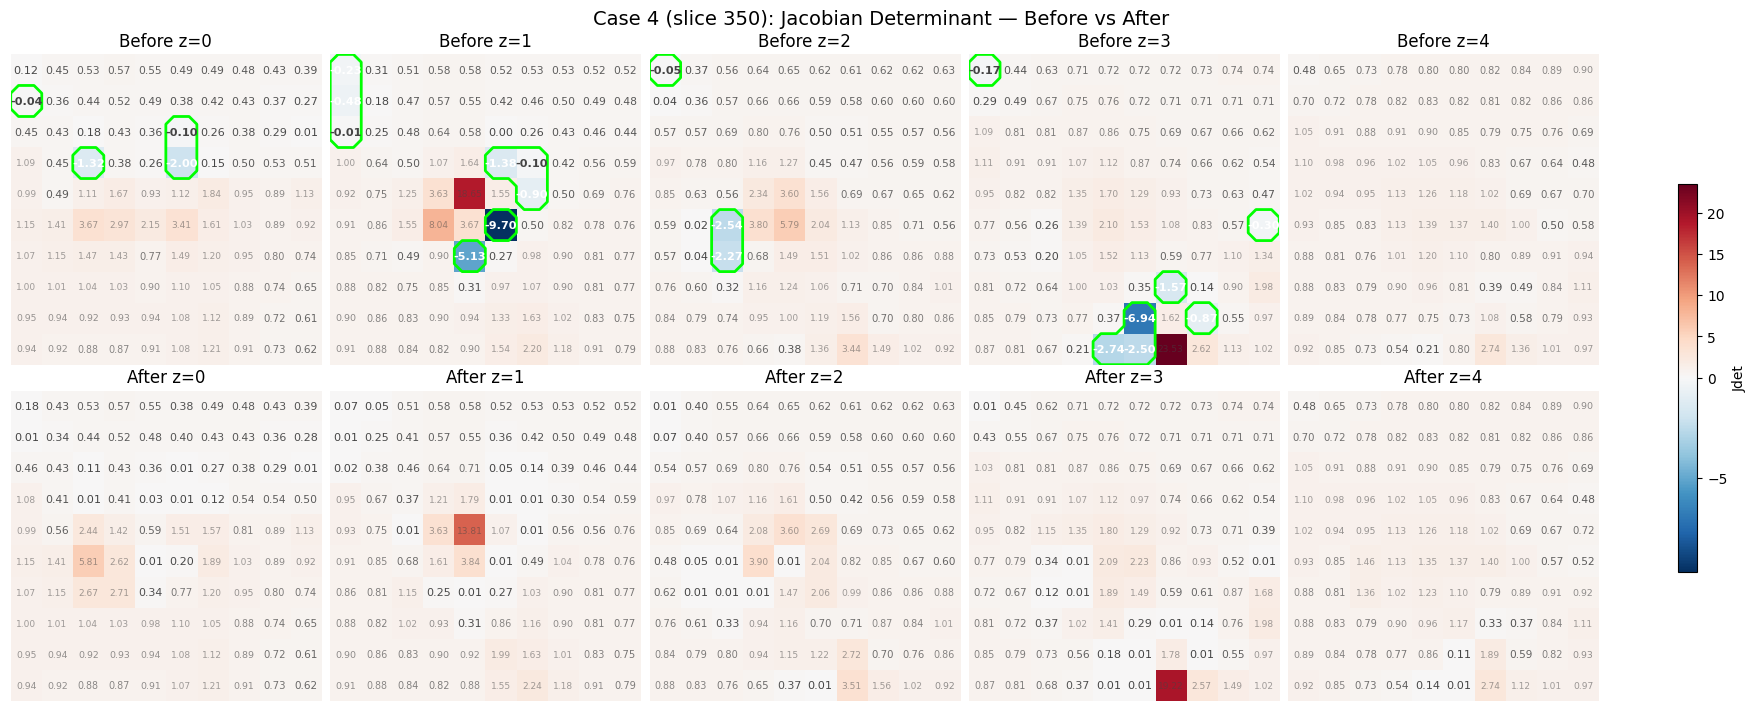

In [10]:
from matplotlib.colors import TwoSlopeNorm

CMAP = "RdBu_r"
NEG_CONTOUR_COLOR = "lime"


def _annotate_neg_contour(ax, jac_2d, threshold=0.0):
    """Overlay a contour at threshold to highlight negative-Jdet regions."""
    mask = (jac_2d <= threshold).astype(float)
    if not mask.any():
        return
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    padded = np.pad(mask, 1, mode="constant", constant_values=0)
    ph, pw = padded.shape
    mask_up = np.repeat(np.repeat(padded, 2, axis=0), 2, axis=1)
    ys = np.linspace(-1.25, ph - 1.75, 2 * ph)
    xs = np.linspace(-1.25, pw - 1.75, 2 * pw)
    X, Y = np.meshgrid(xs, ys)
    ax.contour(X, Y, mask_up, levels=[0.5], colors=NEG_CONTOUR_COLOR,
               linewidths=2.0, linestyles="-")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


def _annotate_jdet_values(ax, jac_2d, max_dim=25):
    """Print Jdet values on each pixel for small grids."""
    h, w = jac_2d.shape
    if max(h, w) > max_dim:
        return
    base_fontsize = min(6.5, max(3.5, 110 / max(h, w)))
    for row in range(h):
        for col in range(w):
            val = jac_2d[row, col]
            color = "white" if val < -0.2 else "#444444"
            weight = "bold" if val <= 0 else "normal"
            t = float(np.clip(val, 0, 1))
            alpha = 1.0 - 0.5 * t * t
            fontsize = base_fontsize * (1.0 + 0.25 * (1.0 - t * t))
            ax.text(col, row, f"{val:.2f}", ha="center", va="center",
                    fontsize=fontsize, color=color, alpha=alpha,
                    fontweight=weight)


def plot_jdet_slices(dvf_before, dvf_after, title_prefix=""):
    """Plot before/after Jdet heatmaps for every z-slice."""
    jdet_b = jacobian_det3D(dvf_before)
    jdet_a = jacobian_det3D(dvf_after)
    D = jdet_b.shape[0]

    vmin = min(jdet_b.min(), jdet_a.min(), -0.5)
    vmax = max(jdet_b.max(), jdet_a.max(), 1.0)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, axes = plt.subplots(2, D, figsize=(3.5 * D, 7),
                             constrained_layout=True)
    if D == 1:
        axes = axes[:, np.newaxis]
    for z in range(D):
        ax_b = axes[0, z]
        im = ax_b.imshow(jdet_b[z], norm=norm, cmap=CMAP, interpolation='nearest')
        _annotate_neg_contour(ax_b, jdet_b[z])
        _annotate_jdet_values(ax_b, jdet_b[z])
        ax_b.set_title(f'Before z={z}')
        ax_b.axis('off')

        ax_a = axes[1, z]
        ax_a.imshow(jdet_a[z], norm=norm, cmap=CMAP, interpolation='nearest')
        _annotate_neg_contour(ax_a, jdet_a[z])
        _annotate_jdet_values(ax_a, jdet_a[z])
        ax_a.set_title(f'After z={z}')
        ax_a.axis('off')

    fig.colorbar(im, ax=axes, shrink=0.6, label='Jdet')
    fig.suptitle(f'{title_prefix} Jacobian Determinant — Before vs After', fontsize=14)
    plt.show()


plot_jdet_slices(dvf_4, phi_4, title_prefix="Case 4 (slice 350):")

---
## Visualisation — Additional Cases

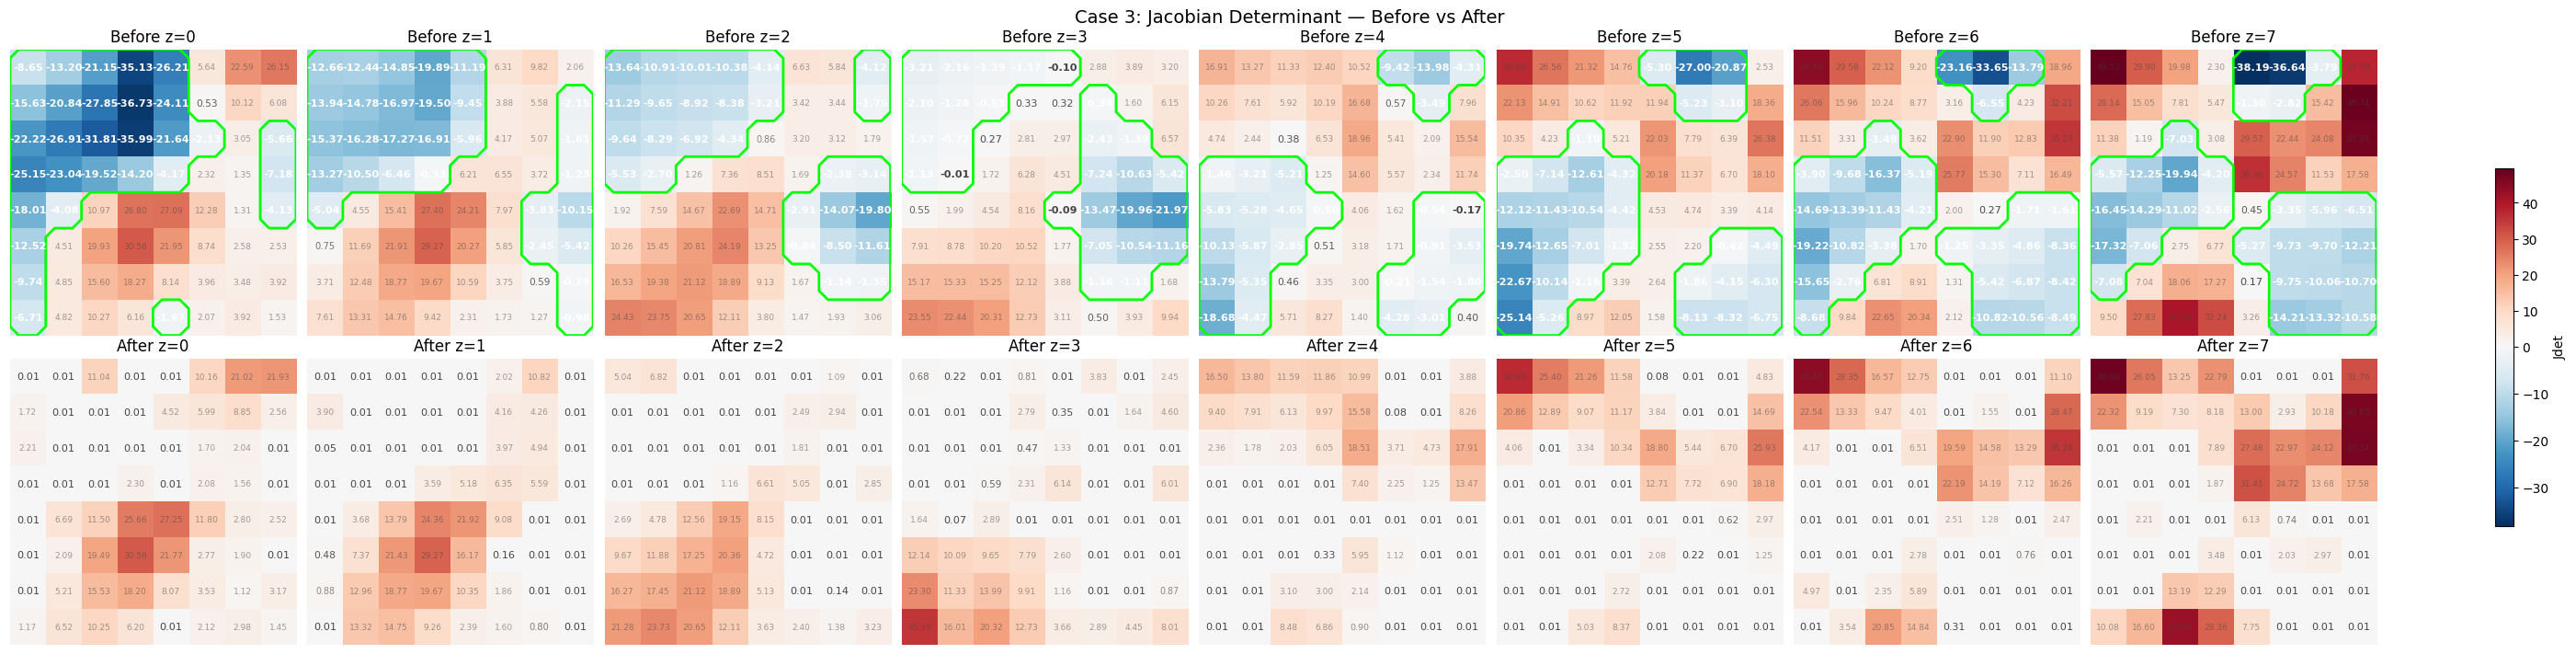

In [11]:
plot_jdet_slices(dvf_3, phi_3, title_prefix="Case 3:")

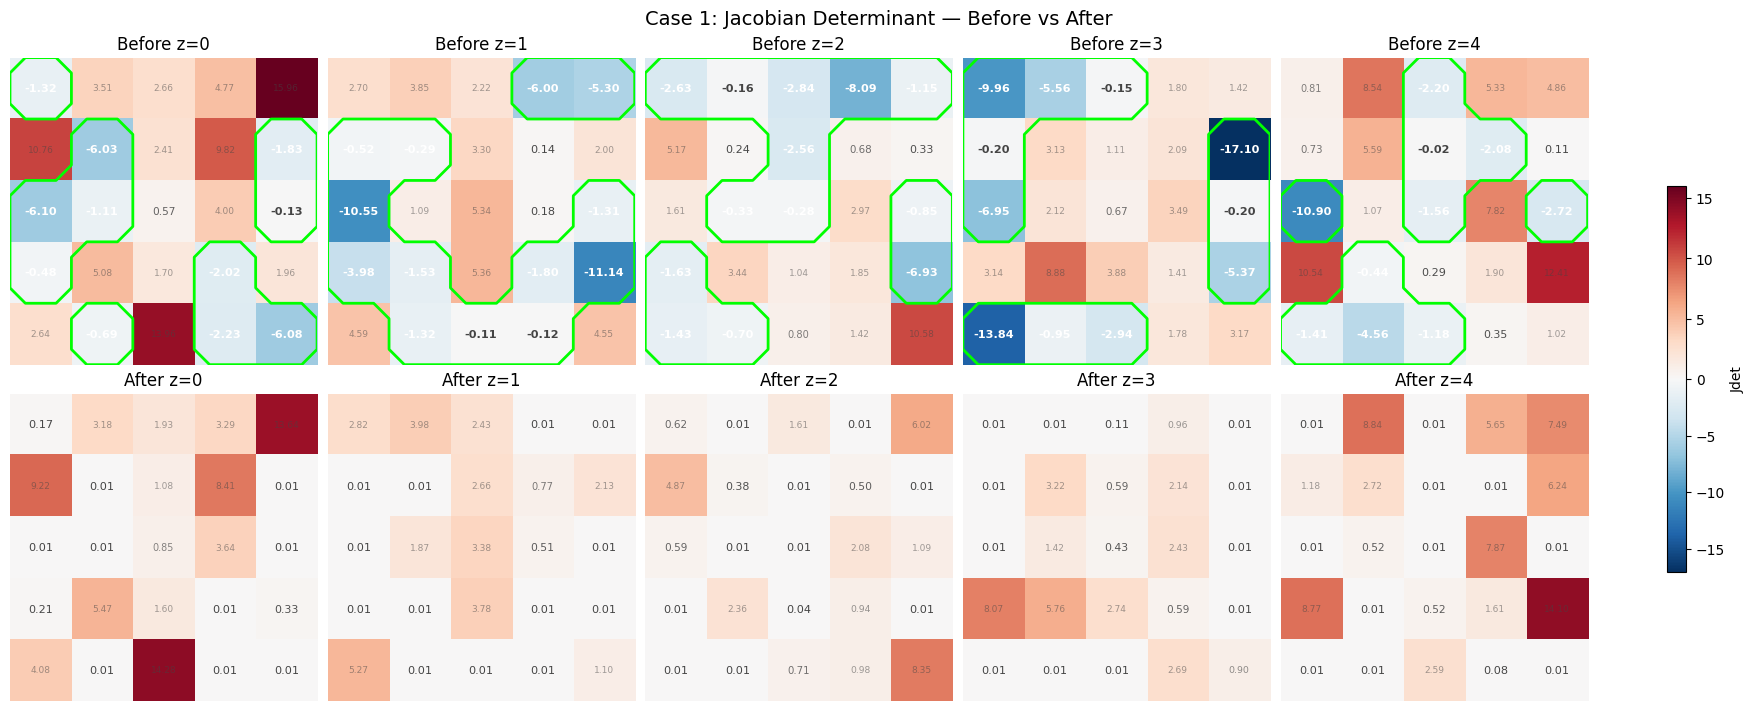

In [12]:
plot_jdet_slices(dvf_1, phi_1, title_prefix="Case 1:")

---
## Summary

All test cases should report **0 negative Jacobian determinants** after correction,
with `min_jdet >= threshold (0.01)`.

| Case | Source | Grid | Description |
|------|--------|------|-------------|
| 1 | Synthetic | 5×5×5 | Random DVF (seed 42, mag 2.0) |
| 2 | Synthetic | 4×6×5 | Random DVF, non-cubic (seed 123, mag 1.5) |
| 3 | Synthetic | 8×8×8 | Upscaled from 3×3×3 (seed 7, mag 4.0) |
| 4 | **Real data** | 5×10×10 | Crop around slice 350 worst neg-Jdet cluster |
| 5 | **Real data** | 5×10×10 | Crop around slice 200 worst neg-Jdet cluster |
| 6 | **Real data** | 5×10×10 | Crop around slice 90 worst neg-Jdet cluster |